# Global vs Per-Class Feature Importance Analysis

### Import Libraries and Setup Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

global_feature_file = r"C:/Users/AGFirass/Documents/GitHub/Transformer-Based-DDoS-Detection/notebooks/feature_importance/global_feature_importance/xgboost_feature_importance_gain.csv"
per_class_folder = r"C:/Users/AGFirass/Documents/GitHub/Transformer-Based-DDoS-Detection/notebooks/feature_importance/per_class_feature_importance/per_class_feature_importance_results"

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Global Feature Importance

In [3]:
print("Loading global feature importance...")
global_features = pd.read_csv(global_feature_file)

print(f"Global feature importance shape: {global_features.shape}")
print(f"Columns: {global_features.columns.tolist()}")
print(f"\nTop 10 global features:")
print(global_features.head(10))

# Basic statistics
print(f"\nGlobal Feature Importance Statistics:")
print(f"Total features: {len(global_features)}")
print(f"Mean importance: {global_features['importance'].mean():.6f}")
print(f"Max importance: {global_features['importance'].max():.6f}")
print(f"Min importance: {global_features['importance'].min():.6f}")
print(f"Non-zero features: {(global_features['importance'] > 0).sum()}")

Loading global feature importance...
Global feature importance shape: (82, 2)
Columns: ['feature', 'importance']

Top 10 global features:
                  feature  importance
0          ACK Flag Count    0.320937
1        act_data_pkt_fwd    0.148958
2    Avg Fwd Segment Size    0.066706
3                 Inbound    0.052926
4                Idle Std    0.042255
5      Packet Length Mean    0.037957
6  Fwd Packet Length Mean    0.036736
7     Average Packet Size    0.034882
8       Min Packet Length    0.033479
9       Max Packet Length    0.021345

Global Feature Importance Statistics:
Total features: 82
Mean importance: 0.012195
Max importance: 0.320937
Min importance: 0.000000
Non-zero features: 70


### Load Per-Class Feature Importance Files

In [4]:
print("Loading per-class feature importance files...")

per_class_files = [f for f in os.listdir(per_class_folder) if f.endswith('.csv')]
print(f"Found {len(per_class_files)} per-class files:")

per_class_data = {}
class_names = []

for file in per_class_files:
    # Extract class name from filename
    class_name = file.replace('_feature_importance.csv', '').replace('.csv', '')
    class_names.append(class_name)

    # Load the file
    file_path = os.path.join(per_class_folder, file)
    df = pd.read_csv(file_path)

    per_class_data[class_name] = df
    print(f"  ✓ {class_name}: {df.shape[0]} features")

print(f"\nLoaded data for {len(per_class_data)} classes:")
print(class_names)

Loading per-class feature importance files...
Found 12 per-class files:
  ✓ benign: 81 features
  ✓ DrDoS_DNS: 81 features
  ✓ DrDoS_LDAP: 81 features
  ✓ DrDoS_MSSQL: 81 features
  ✓ DrDoS_NetBIOS: 81 features
  ✓ DrDoS_NTP: 81 features
  ✓ DrDoS_SNMP: 81 features
  ✓ DrDoS_SSDP: 81 features
  ✓ DrDoS_UDP: 81 features
  ✓ Syn: 81 features
  ✓ TFTP: 81 features
  ✓ UDPLag: 81 features

Loaded data for 12 classes:
['benign', 'DrDoS_DNS', 'DrDoS_LDAP', 'DrDoS_MSSQL', 'DrDoS_NetBIOS', 'DrDoS_NTP', 'DrDoS_SNMP', 'DrDoS_SSDP', 'DrDoS_UDP', 'Syn', 'TFTP', 'UDPLag']


### Create Combined Feature Importance Matrix

In [5]:
print("Creating combined feature importance matrix...")

# Get all unique features (use global as reference)
all_features = global_features['feature'].tolist()
print(f"Total unique features: {len(all_features)}")

# Create comparison dataframe
comparison_df = pd.DataFrame({'feature': all_features})

# Add global importance
global_importance_dict = dict(zip(global_features['feature'], global_features['importance']))
comparison_df['global_importance'] = comparison_df['feature'].map(global_importance_dict)

# Add per-class importance
for class_name, class_df in per_class_data.items():
    class_importance_dict = dict(zip(class_df['feature'], class_df['importance']))
    comparison_df[f'{class_name}_importance'] = comparison_df['feature'].map(class_importance_dict).fillna(0)

print(f"Comparison matrix shape: {comparison_df.shape}")
print(f"Columns: {comparison_df.columns.tolist()}")

# Calculate additional statistics
comparison_df['per_class_mean'] = comparison_df.iloc[:, 2:].mean(axis=1)  # Skip feature and global columns
comparison_df['per_class_std'] = comparison_df.iloc[:, 2:-1].std(axis=1)  # Skip mean column
comparison_df['per_class_max'] = comparison_df.iloc[:, 2:-2].max(axis=1)  # Skip std and mean columns

print(f"\nFirst few rows of comparison matrix:")
print(comparison_df.head())

Creating combined feature importance matrix...
Total unique features: 82
Comparison matrix shape: (82, 14)
Columns: ['feature', 'global_importance', 'benign_importance', 'DrDoS_DNS_importance', 'DrDoS_LDAP_importance', 'DrDoS_MSSQL_importance', 'DrDoS_NetBIOS_importance', 'DrDoS_NTP_importance', 'DrDoS_SNMP_importance', 'DrDoS_SSDP_importance', 'DrDoS_UDP_importance', 'Syn_importance', 'TFTP_importance', 'UDPLag_importance']

First few rows of comparison matrix:
                feature  global_importance  benign_importance  \
0        ACK Flag Count           0.320937                0.0   
1      act_data_pkt_fwd           0.148958                0.0   
2  Avg Fwd Segment Size           0.066706                0.0   
3               Inbound           0.052926                0.0   
4              Idle Std           0.042255                0.0   

   DrDoS_DNS_importance  DrDoS_LDAP_importance  DrDoS_MSSQL_importance  \
0                   0.0                    0.0                     0

In [6]:
comparison_df

,feature,global_importance,benign_importance,DrDoS_DNS_importance,DrDoS_LDAP_importance,DrDoS_MSSQL_importance,DrDoS_NetBIOS_importance,DrDoS_NTP_importance,DrDoS_SNMP_importance,DrDoS_SSDP_importance,DrDoS_UDP_importance,Syn_importance,TFTP_importance,UDPLag_importance,per_class_mean,per_class_std,per_class_max
0,ACK Flag Count,0.320937,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,act_data_pkt_fwd,0.148958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Avg Fwd Segment Size,0.066706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Inbound,0.052926,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Idle Std,0.042255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,Bwd Avg Packets/Bulk,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
78,Fwd Avg Bytes/Bulk,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
79,Fwd Avg Packets/Bulk,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
80,ECE Flag Count,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Global vs Per-Class Comparison Analysis

In [7]:
# Compare global vs per-class importance
print("GLOBAL vs PER-CLASS FEATURE IMPORTANCE COMPARISON")
print("="*60)

# Correlation between global and per-class mean
correlation = comparison_df['global_importance'].corr(comparison_df['per_class_mean'])
print(f"Correlation between global and per-class mean importance: {correlation:.4f}")

# Top features comparison
top_n = 20
print(f"\nTop {top_n} Global vs Per-Class Mean Importance:")
print("-" * 80)
print(f"{'Rank':<4} {'Feature':<35} {'Global':<12} {'Per-Class Mean':<15} {'Difference':<10}")
print("-" * 80)

# Sort by global importance and compare
top_global = comparison_df.nlargest(top_n, 'global_importance')

for i, (_, row) in enumerate(top_global.iterrows(), 1):
    diff = row['global_importance'] - row['per_class_mean']
    print(f"{i:<4} {row['feature']:<35} {row['global_importance']:<12.6f} {row['per_class_mean']:<15.6f} {diff:<10.6f}")

# Features with high variance across classes
print(f"\nFeatures with Highest Variance Across Classes:")
print("-" * 60)
high_variance_features = comparison_df.nlargest(10, 'per_class_std')
for i, (_, row) in enumerate(high_variance_features.iterrows(), 1):
    print(f"{i:<3} {row['feature']:<35} (std: {row['per_class_std']:.6f})")

GLOBAL vs PER-CLASS FEATURE IMPORTANCE COMPARISON
Correlation between global and per-class mean importance: -0.0335

Top 20 Global vs Per-Class Mean Importance:
--------------------------------------------------------------------------------
Rank Feature                             Global       Per-Class Mean  Difference
--------------------------------------------------------------------------------
1    ACK Flag Count                      0.320937     0.000000        0.320937  
2    act_data_pkt_fwd                    0.148958     0.000000        0.148958  
3    Avg Fwd Segment Size                0.066706     0.000000        0.066706  
4    Inbound                             0.052926     0.000000        0.052926  
5    Idle Std                            0.042255     0.000000        0.042255  
6    Packet Length Mean                  0.037957     0.000000        0.037957  
7    Fwd Packet Length Mean              0.036736     0.000000        0.036736  
8    Average Packet Size     

### Heatmap Visualization - Top Features Across Classes

Creating feature importance heatmap...


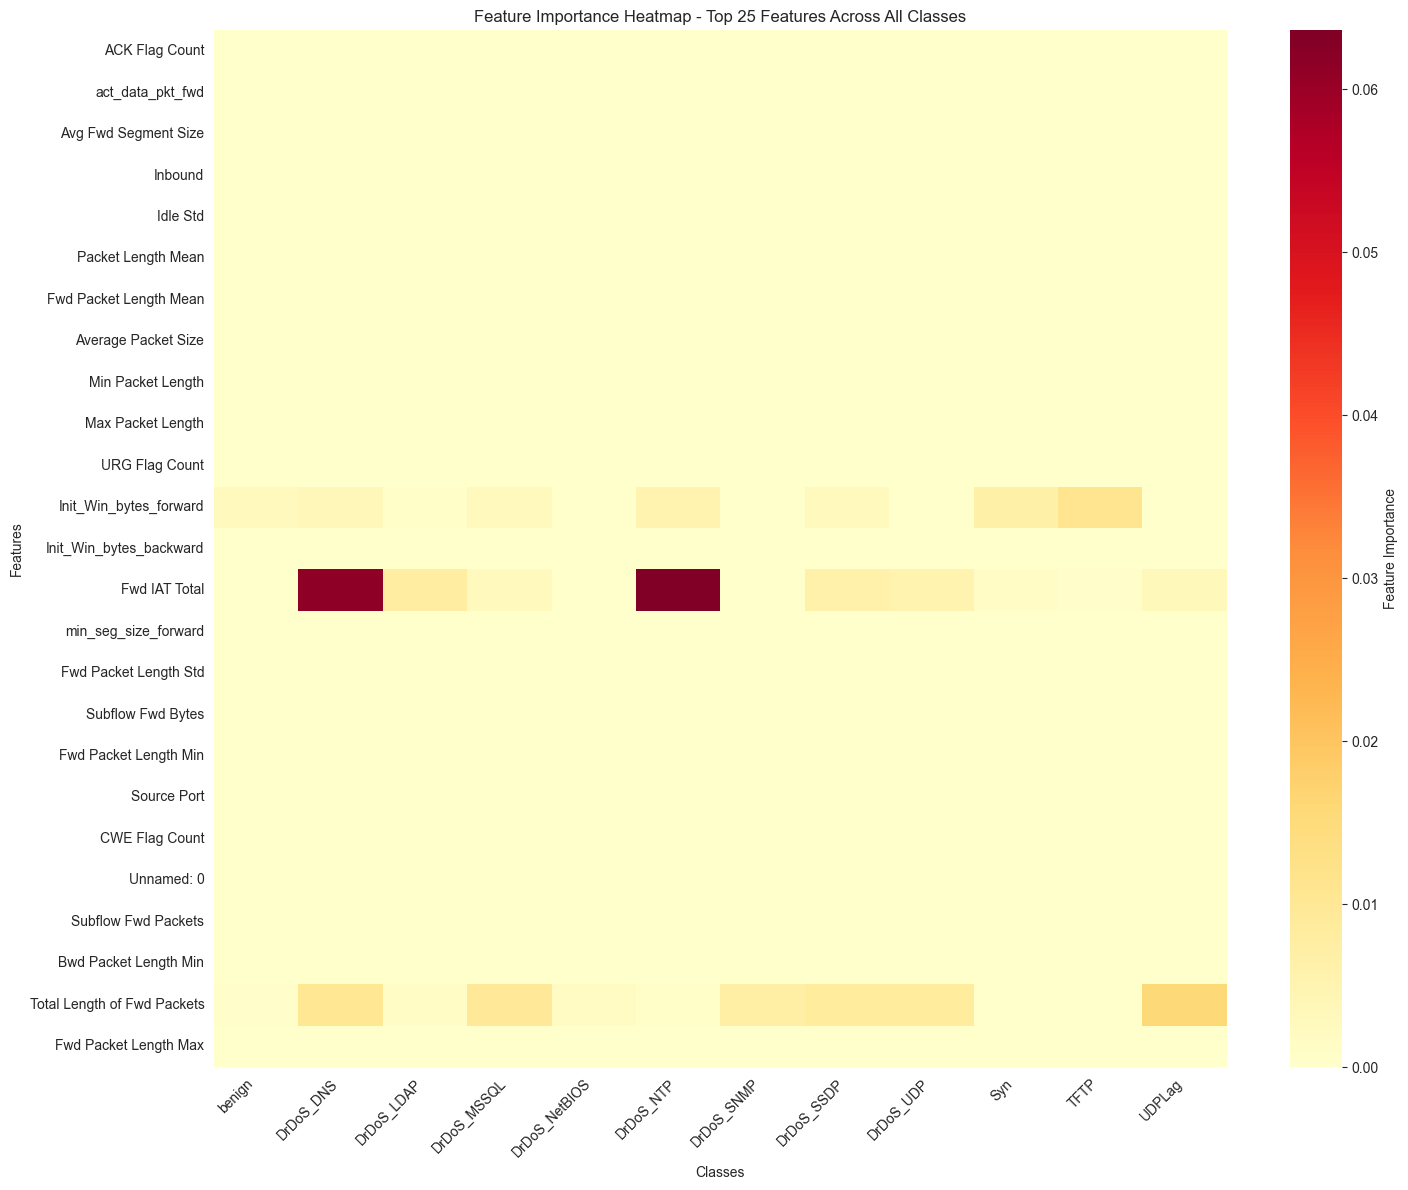

Heatmap created successfully!


In [8]:
# Create heatmap of top features across all classes
print("Creating feature importance heatmap...")

# Select top N features by global importance
top_n_heatmap = 25
top_features_for_heatmap = comparison_df.nlargest(top_n_heatmap, 'global_importance')

# Prepare data for heatmap
heatmap_data = []
heatmap_features = []
heatmap_classes = []

# Get class columns (exclude feature, global_importance, and calculated columns)
class_columns = [col for col in comparison_df.columns if col.endswith('_importance') and col != 'global_importance']
heatmap_classes = [col.replace('_importance', '') for col in class_columns]

for _, row in top_features_for_heatmap.iterrows():
    feature_name = row['feature']
    heatmap_features.append(feature_name)

    feature_importances = []
    for class_col in class_columns:
        feature_importances.append(row[class_col])

    heatmap_data.append(feature_importances)

# Create heatmap
plt.figure(figsize=(15, 12))
heatmap_array = np.array(heatmap_data)

sns.heatmap(heatmap_array,
            xticklabels=heatmap_classes,
            yticklabels=heatmap_features,
            annot=False,
            cmap='YlOrRd',
            cbar_kws={'label': 'Feature Importance'},
            fmt='.3f')

plt.title(f'Feature Importance Heatmap - Top {top_n_heatmap} Features Across All Classes')
plt.xlabel('Classes')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap created successfully!")

### Class-Specific vs Global Feature Analysis

In [9]:
# Find features that are important globally but not class-specific, and vice versa
print("CLASS-SPECIFIC vs GLOBAL FEATURE ANALYSIS")
print("="*50)

# Define thresholds
global_threshold = np.percentile(comparison_df['global_importance'], 80)  # Top 20% globally
class_threshold = np.percentile(comparison_df['per_class_max'], 80)  # Top 20% in any class

print(f"Global importance threshold (80th percentile): {global_threshold:.6f}")
print(f"Per-class max importance threshold (80th percentile): {class_threshold:.6f}")

# Category 1: High global importance, low class-specific importance
global_high_class_low = comparison_df[
    (comparison_df['global_importance'] > global_threshold) &
    (comparison_df['per_class_max'] < class_threshold)
]

print(f"\n1. HIGH GLOBAL, LOW CLASS-SPECIFIC ({len(global_high_class_low)} features):")
print("   Features important in combined model but not distinctive for any single class:")
for i, (_, row) in enumerate(global_high_class_low.head(10).iterrows(), 1):
    print(f"   {i:2d}. {row['feature']:<40} (Global: {row['global_importance']:.4f}, Max Class: {row['per_class_max']:.4f})")

# Category 2: Low global importance, high class-specific importance
global_low_class_high = comparison_df[
    (comparison_df['global_importance'] < global_threshold) &
    (comparison_df['per_class_max'] > class_threshold)
]

print(f"\n2. LOW GLOBAL, HIGH CLASS-SPECIFIC ({len(global_low_class_high)} features):")
print("   Features not important globally but very important for specific classes:")
for i, (_, row) in enumerate(global_low_class_high.head(10).iterrows(), 1):
    # Find which class has the highest importance for this feature
    class_importances = {col.replace('_importance', ''): row[col] for col in class_columns}
    best_class = max(class_importances, key=class_importances.get)
    best_importance = class_importances[best_class]

    print(f"   {i:2d}. {row['feature']:<40} (Global: {row['global_importance']:.4f}, {best_class}: {best_importance:.4f})")

# Category 3: High both global and class-specific
high_both = comparison_df[
    (comparison_df['global_importance'] > global_threshold) &
    (comparison_df['per_class_max'] > class_threshold)
]

print(f"\n3. HIGH BOTH GLOBAL AND CLASS-SPECIFIC ({len(high_both)} features):")
print("   Universally important features:")
for i, (_, row) in enumerate(high_both.head(10).iterrows(), 1):
    print(f"   {i:2d}. {row['feature']:<40} (Global: {row['global_importance']:.4f}, Max Class: {row['per_class_max']:.4f})")

CLASS-SPECIFIC vs GLOBAL FEATURE ANALYSIS
Global importance threshold (80th percentile): 0.008876
Per-class max importance threshold (80th percentile): 0.000000

1. HIGH GLOBAL, LOW CLASS-SPECIFIC (0 features):
   Features important in combined model but not distinctive for any single class:

2. LOW GLOBAL, HIGH CLASS-SPECIFIC (8 features):
   Features not important globally but very important for specific classes:
    1. Total Length of Fwd Packets              (Global: 0.0049, UDPLag: 0.0158)
    2. Flow Bytes/s                             (Global: 0.0047, DrDoS_SSDP: 0.1149)
    3. Fwd Packets/s                            (Global: 0.0021, DrDoS_SSDP: 0.0727)
    4. Idle Mean                                (Global: 0.0015, Syn: 0.0029)
    5. Active Mean                              (Global: 0.0012, benign: 0.0262)
    6. Bwd Packet Length Max                    (Global: 0.0010, DrDoS_MSSQL: 0.0020)
    7. Fwd PSH Flags                            (Global: 0.0010, DrDoS_NTP: 0.0010)
 

### Per-Class Feature Ranking Comparison

In [10]:
# Compare feature rankings across classes
print("PER-CLASS FEATURE RANKING COMPARISON")
print("="*40)

# Create ranking comparison for top features
top_features_global = comparison_df.nlargest(20, 'global_importance')['feature'].tolist()

print("Rankings of top global features across different classes:")
print("(1 = most important in that class, lower numbers = higher importance)\n")

ranking_data = []
for feature in top_features_global[:15]:  # Top 15 for readability
    feature_row = comparison_df[comparison_df['feature'] == feature].iloc[0]

    rankings = {}
    for class_col in class_columns:
        class_name = class_col.replace('_importance', '')
        class_df = per_class_data[class_name]

        # Find rank of this feature in this class
        try:
            rank = class_df[class_df['feature'] == feature].index[0] + 1
        except:
            rank = len(class_df) + 1  # If feature not found, give it last rank

        rankings[class_name] = rank

    ranking_data.append({'feature': feature, **rankings})

    # Print feature ranking
    rankings_str = " | ".join([f"{cls}:{rank:3d}" for cls, rank in rankings.items()])
    print(f"{feature:<35} | {rankings_str}")

# Create ranking dataframe for further analysis
ranking_df = pd.DataFrame(ranking_data)
print(f"\nRanking comparison completed!")

PER-CLASS FEATURE RANKING COMPARISON
Rankings of top global features across different classes:
(1 = most important in that class, lower numbers = higher importance)

ACK Flag Count                      | benign: 82 | DrDoS_DNS: 82 | DrDoS_LDAP: 82 | DrDoS_MSSQL: 82 | DrDoS_NetBIOS: 82 | DrDoS_NTP: 82 | DrDoS_SNMP: 82 | DrDoS_SSDP: 82 | DrDoS_UDP: 82 | Syn: 82 | TFTP: 82 | UDPLag: 82
act_data_pkt_fwd                    | benign: 82 | DrDoS_DNS: 82 | DrDoS_LDAP: 82 | DrDoS_MSSQL: 82 | DrDoS_NetBIOS: 82 | DrDoS_NTP: 82 | DrDoS_SNMP: 82 | DrDoS_SSDP: 82 | DrDoS_UDP: 82 | Syn: 82 | TFTP: 82 | UDPLag: 82
Avg Fwd Segment Size                | benign: 82 | DrDoS_DNS: 82 | DrDoS_LDAP: 82 | DrDoS_MSSQL: 82 | DrDoS_NetBIOS: 82 | DrDoS_NTP: 82 | DrDoS_SNMP: 82 | DrDoS_SSDP: 82 | DrDoS_UDP: 82 | Syn: 82 | TFTP: 82 | UDPLag: 82
Inbound                             | benign: 82 | DrDoS_DNS: 82 | DrDoS_LDAP: 82 | DrDoS_MSSQL: 82 | DrDoS_NetBIOS: 82 | DrDoS_NTP: 82 | DrDoS_SNMP: 82 | DrDoS_SSDP: 82 | Dr

### Statistical Analysis and Correlations

STATISTICAL ANALYSIS


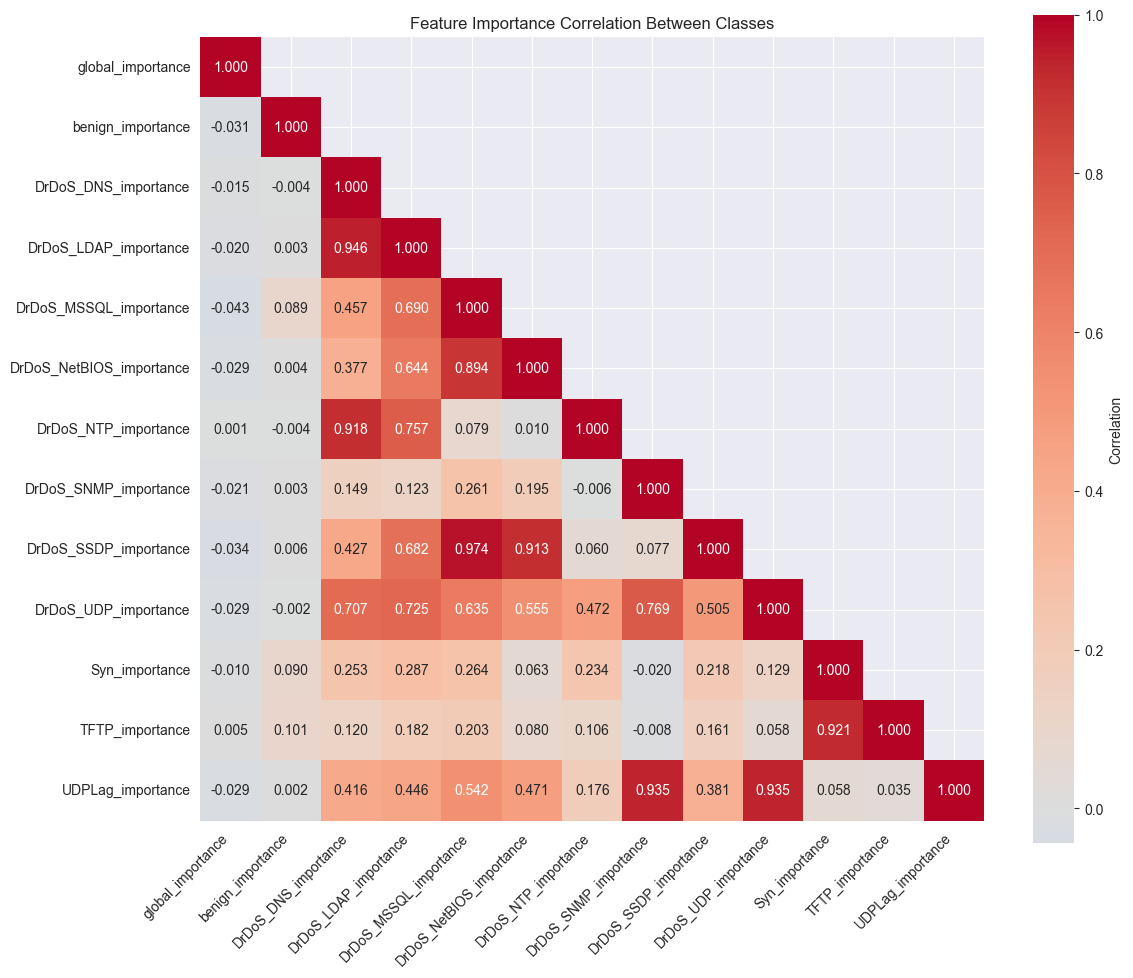


Most similar classes (highest correlation):
  1. DrDoS_MSSQL     vs DrDoS_SSDP     : 0.9738
  2. DrDoS_DNS       vs DrDoS_LDAP     : 0.9458
  3. DrDoS_SNMP      vs UDPLag         : 0.9353
  4. DrDoS_UDP       vs UDPLag         : 0.9352
  5. Syn             vs TFTP           : 0.9209

Most different classes (lowest correlation):
  1. global          vs UDPLag         : -0.0291
  2. global          vs DrDoS_UDP      : -0.0292
  3. global          vs benign         : -0.0308
  4. global          vs DrDoS_SSDP     : -0.0339
  5. global          vs DrDoS_MSSQL    : -0.0432

Feature Importance Distribution Statistics:
Global importance - Mean: 0.012195, Std: 0.039981
Per-class mean - Mean: 0.000625, Std: 0.002604


In [11]:
# Statistical analysis of feature importance patterns
print("STATISTICAL ANALYSIS")
print("="*25)

# Correlation matrix between classes
class_importance_cols = [col for col in comparison_df.columns if col.endswith('_importance')]
correlation_matrix = comparison_df[class_importance_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix), k=1)
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            mask=mask,
            square=True,
            fmt='.3f',
            cbar_kws={'label': 'Correlation'})

plt.title('Feature Importance Correlation Between Classes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find most and least correlated class pairs
correlation_pairs = []
classes = [col.replace('_importance', '') for col in class_importance_cols]

for i in range(len(classes)):
    for j in range(i+1, len(classes)):
        class1, class2 = classes[i], classes[j]
        corr = correlation_matrix.iloc[i, j]
        correlation_pairs.append((class1, class2, corr))

correlation_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nMost similar classes (highest correlation):")
for i, (c1, c2, corr) in enumerate(correlation_pairs[:5]):
    print(f"  {i+1}. {c1:<15} vs {c2:<15}: {corr:.4f}")

print("\nMost different classes (lowest correlation):")
for i, (c1, c2, corr) in enumerate(correlation_pairs[-5:]):
    print(f"  {i+1}. {c1:<15} vs {c2:<15}: {corr:.4f}")

# Feature importance distribution statistics
print(f"\nFeature Importance Distribution Statistics:")
print(f"Global importance - Mean: {comparison_df['global_importance'].mean():.6f}, Std: {comparison_df['global_importance'].std():.6f}")
print(f"Per-class mean - Mean: {comparison_df['per_class_mean'].mean():.6f}, Std: {comparison_df['per_class_mean'].std():.6f}")

### Generate Summary Report and Save Results

In [12]:
# Generate comprehensive summary report
print("COMPREHENSIVE SUMMARY REPORT")
print("="*35)

# Overall statistics
total_features = len(comparison_df)
significant_global = (comparison_df['global_importance'] > 0.01).sum()
significant_any_class = (comparison_df['per_class_max'] > 0.01).sum()

print(f"Dataset Summary:")
print(f"  • Total features analyzed: {total_features}")
print(f"  • Features with significant global importance (>0.01): {significant_global}")
print(f"  • Features with significant importance in any class (>0.01): {significant_any_class}")
print(f"  • Number of classes: {len(class_names)}")

# Top features summary
print(f"\nTop 10 Features Summary:")
top_10_comparison = comparison_df.nlargest(10, 'global_importance')[['feature', 'global_importance', 'per_class_mean', 'per_class_max']]
print(top_10_comparison.round(6))

# Class-specific insights
print(f"\nClass-Specific Insights:")
for class_name in class_names[:5]:  # Show first 5 classes
    class_col = f"{class_name}_importance"
    top_feature_for_class = comparison_df.nlargest(1, class_col).iloc[0]
    print(f"  • {class_name}: Top feature is '{top_feature_for_class['feature']}' (importance: {top_feature_for_class[class_col]:.4f})")

# Save results
results_dir = "feature_importance_analysis_results"
os.makedirs(results_dir, exist_ok=True)

# Save comparison matrix
comparison_filename = f"{results_dir}/complete_feature_comparison.csv"
comparison_df.to_csv(comparison_filename, index=False)
print(f"\n✓ Complete comparison saved to: {comparison_filename}")

# Save correlation matrix
correlation_filename = f"{results_dir}/class_correlation_matrix.csv"
correlation_matrix.to_csv(correlation_filename)
print(f"✓ Correlation matrix saved to: {correlation_filename}")

# Save ranking comparison
if 'ranking_df' in locals():
    ranking_filename = f"{results_dir}/feature_ranking_comparison.csv"
    ranking_df.to_csv(ranking_filename, index=False)
    print(f"✓ Feature rankings saved to: {ranking_filename}")

# Save summary statistics
summary_stats = {
    'total_features': total_features,
    'significant_global_features': significant_global,
    'significant_class_features': significant_any_class,
    'num_classes': len(class_names),
    'global_per_class_correlation': comparison_df['global_importance'].corr(comparison_df['per_class_mean']),
    'mean_global_importance': comparison_df['global_importance'].mean(),
    'mean_per_class_importance': comparison_df['per_class_mean'].mean()
}

summary_filename = f"{results_dir}/summary_statistics.txt"
with open(summary_filename, 'w') as f:
    for key, value in summary_stats.items():
        f.write(f"{key}: {value}\n")

print(f"✓ Summary statistics saved to: {summary_filename}")
print(f"\nAll analysis results saved to '{results_dir}' directory!")
print("Analysis completed successfully! 🎉")

COMPREHENSIVE SUMMARY REPORT
Dataset Summary:
  • Total features analyzed: 82
  • Features with significant global importance (>0.01): 15
  • Features with significant importance in any class (>0.01): 6
  • Number of classes: 12

Top 10 Features Summary:
                  feature  global_importance  per_class_mean  per_class_max
0          ACK Flag Count           0.320937             0.0            0.0
1        act_data_pkt_fwd           0.148958             0.0            0.0
2    Avg Fwd Segment Size           0.066706             0.0            0.0
3                 Inbound           0.052926             0.0            0.0
4                Idle Std           0.042255             0.0            0.0
5      Packet Length Mean           0.037957             0.0            0.0
6  Fwd Packet Length Mean           0.036736             0.0            0.0
7     Average Packet Size           0.034882             0.0            0.0
8       Min Packet Length           0.033479             0.0 